In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
# Ensure the CSV path matches your local file location
df = pd.read_csv("Data/news_articles.csv")

# Display shape and basic info
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (2096, 12)


,author,published,title,text,language,site_url,main_img_url,type,label,title_without_stopwords,text_without_stopwords,hasImage
0,Barracuda Brigade,2016-10-26T21:41:00.000+03:00,muslims busted they stole millions in govt ben...,print they should pay all the back all the mon...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,muslims busted stole millions govt benefits,print pay back money plus interest entire fami...,1.0
1,reasoning with facts,2016-10-29T08:47:11.259+03:00,re why did attorney general loretta lynch plea...,why did attorney general loretta lynch plead t...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,attorney general loretta lynch plead fifth,attorney general loretta lynch plead fifth bar...,1.0
2,Barracuda Brigade,2016-10-31T01:41:49.479+02:00,breaking weiner cooperating with fbi on hillar...,red state \nfox news sunday reported this mor...,english,100percentfedup.com,http://bb4sp.com/wp-content/uploads/2016/10/Fu...,bias,Real,breaking weiner cooperating fbi hillary email ...,red state fox news sunday reported morning ant...,1.0
3,Fed Up,2016-11-01T05:22:00.000+02:00,pin drop speech by father of daughter kidnappe...,email kayla mueller was a prisoner and torture...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,pin drop speech father daughter kidnapped kill...,email kayla mueller prisoner tortured isis cha...,1.0
4,Fed Up,2016-11-01T21:56:00.000+02:00,fantastic trumps point plan to reform healthc...,email healthcare reform to make america great ...,english,100percentfedup.com,http://100percentfedup.com/wp-content/uploads/...,bias,Real,fantastic trumps point plan reform healthcare ...,email healthcare reform make america great sin...,1.0


In [3]:
# pre processing and cleaning

# 1. Check for missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# 2. Drop rows with missing text or labels to avoid errors
df = df.dropna(subset=['text', 'title', 'label'])

# 3. Create a unified 'content' column (Title + Text)
df['content'] = df['title'] + " " + df['text']

# 4. Standardize the labels
# We want to see what unique labels exist (e.g., 'Real', 'Fake')
print("\nUnique Labels found:", df['label'].unique())

# (Optional) If your labels are not just 'Real'/'Fake', you might need to map them.
# For this code, we assume the dataset has 'Real' and 'Fake' (or similar distinct classes).

Missing values before cleaning:
author                      0
published                   0
title                       0
text                       46
language                    1
site_url                    1
main_img_url                1
type                        1
label                       1
title_without_stopwords     2
text_without_stopwords     50
hasImage                    1
dtype: int64

Unique Labels found: ['Real' 'Fake']


/tmp/ipykernel_22793/1295755831.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['content'] = df['title'] + " " + df['text']


/tmp/ipykernel_22793/1713668502.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


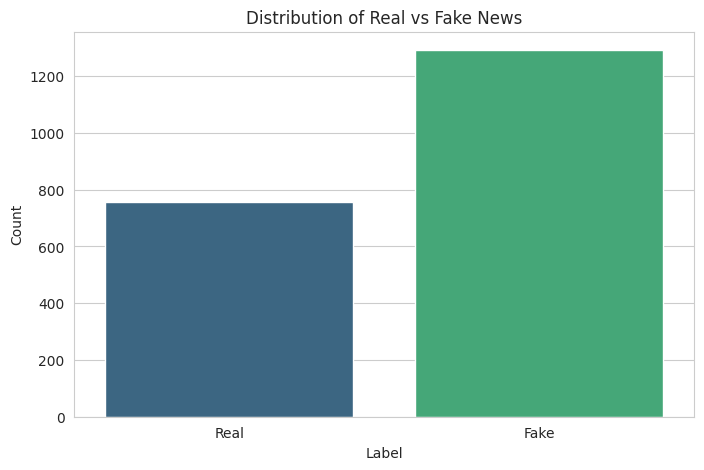

label
Fake    1292
Real     758
Name: count, dtype: int64


In [4]:
# Set plot style
sns.set_style("whitegrid")

# 1. Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Real vs Fake News')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()



# 2. Check data balance programmatically
print(df['label'].value_counts())

In [5]:
#text normalization
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove punctuation
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    # Remove numbers / digits
    text = re.sub(r'\d+', '', text)
    # Remove newlines
    text = re.sub(r'\n', ' ', text)
    return text

# Apply cleaning to the content column
print("Cleaning text data... this may take a moment.")
df['content'] = df['content'].apply(clean_text)

print("Text cleaning complete.")
df[['content', 'label']].head()

Cleaning text data... this may take a moment.
Text cleaning complete.


,content,label
0,muslims busted they stole millions in govt ben...,Real
1,re why did attorney general loretta lynch plea...,Real
2,breaking weiner cooperating with fbi on hillar...,Real
3,pin drop speech by father of daughter kidnappe...,Real
4,fantastic trumps point plan to reform healthc...,Real


In [6]:
#split data and vectorization

# Define Features (X) and Target (y)
X = df['content']
y = df['label']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize TF-IDF Vectorizer
# max_df=0.7 means ignore terms that appear in more than 70% of documents (too common)
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

# Fit and transform the training data, transform the test data
tfidf_train = vectorizer.fit_transform(X_train)
tfidf_test = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.get_feature_names_out())}")

Vocabulary size: 42377


In [7]:
#model training 


# Initialize the model
model = PassiveAggressiveClassifier(max_iter=50)

# Train the model
model.fit(tfidf_train, y_train)

print("Model training complete.")

Model training complete.


Accuracy: 77.56%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.82      0.80      0.81       249
        Real       0.71      0.73      0.72       161

    accuracy                           0.78       410
   macro avg       0.76      0.77      0.77       410
weighted avg       0.78      0.78      0.78       410



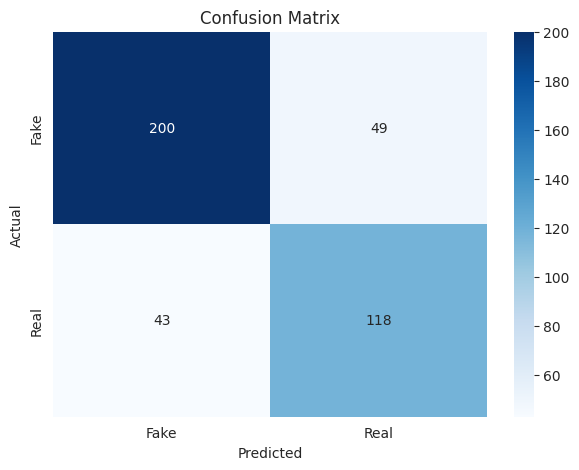

In [15]:
#evaluation 

# Predict on the test set
y_pred = model.predict(tfidf_test)

# Calculate Accuracy
score = accuracy_score(y_test, y_pred)
print(f'Accuracy: {round(score*100, 2)}%')

# Detailed Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [16]:
def predict_news(news_text):
    # 1. Clean the input text using the same function as before
    cleaned_text = clean_text(news_text)
    
    # 2. Transform the text using the ALREADY FITTED vectorizer
    # Note: Do not use fit_transform here, only transform
    input_vector = vectorizer.transform([cleaned_text])
    
    # 3. Predict
    prediction = model.predict(input_vector)
    
    return prediction[0]

# --- TEST IT HERE ---
user_input = input("Enter a news article text to check: ")

if user_input:
    result = predict_news(user_input)
    print(f"\n---------------------------------")
    print(f"The model predicts this news is: **{result}**")
    print(f"---------------------------------")

Enter a news article text to check:  elon musk buys twitter



---------------------------------
The model predicts this news is: **Real**
---------------------------------
